In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
d1=pd.read_csv('/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
d2=pd.read_csv('/content/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')
d3=pd.read_csv('/content/Friday-WorkingHours-Morning.pcap_ISCX.csv')
d4=pd.read_csv('/content/Monday-WorkingHours.pcap_ISCX.csv')
d5=pd.read_csv('/content/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv')
d6=pd.read_csv('/content/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')
d7=pd.read_csv('/content/Tuesday-WorkingHours.pcap_ISCX.csv')
d8=pd.read_csv('/content/Wednesday-workingHours.pcap_ISCX.csv')


In [3]:
df=pd.concat([d1,d2,d3,d4,d5,d6,d7,d8])

In [4]:
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
692698,53,32215,4,2,112,152,28,28,28.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
692699,53,324,2,2,84,362,42,42,42.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
692700,58030,82,2,1,31,6,31,0,15.5,21.92031,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
692701,53,1048635,6,2,192,256,32,32,32.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
df.shape

(2830743, 79)

In [6]:
df.isnull().sum().sort_values(ascending=False)

,0
Flow Bytes/s,1358
Flow Duration,0
Destination Port,0
Total Backward Packets,0
Total Length of Fwd Packets,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [7]:
column_names = list(df.columns)
print(column_names)

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [8]:
df.columns = df.columns.str.strip()

In [9]:
df.shape

(2830743, 79)

In [10]:
df.dtypes

,0
Destination Port,int64
Flow Duration,int64
Total Fwd Packets,int64
Total Backward Packets,int64
Total Length of Fwd Packets,int64
...,...
Idle Mean,float64
Idle Std,float64
Idle Max,int64
Idle Min,int64


In [11]:
print(df['Label'].value_counts())
# percentage distribution
print("\nPercentage:")
print(df['Label'].value_counts(normalize=True) * 100)

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Percentage:
Label
BENIGN                        80.300366
DoS Hulk                       8.162981
PortScan                       5.614427
DDoS                           4.522735
DoS GoldenEye                  0.363615
FTP-Patator                    0.280421
SSH-Patator                    0.208320
DoS slowloris                  0.204752
DoS Slowhttptest               0.194260
Bot                

In [12]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


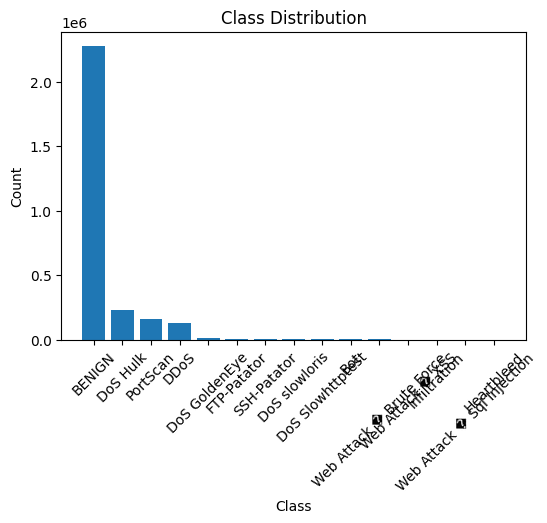

In [13]:
counts = df['Label'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [14]:
print("Infinite values:", np.isinf(df.select_dtypes(include=[float, int])).sum().sum())

Infinite values: 4376


In [15]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

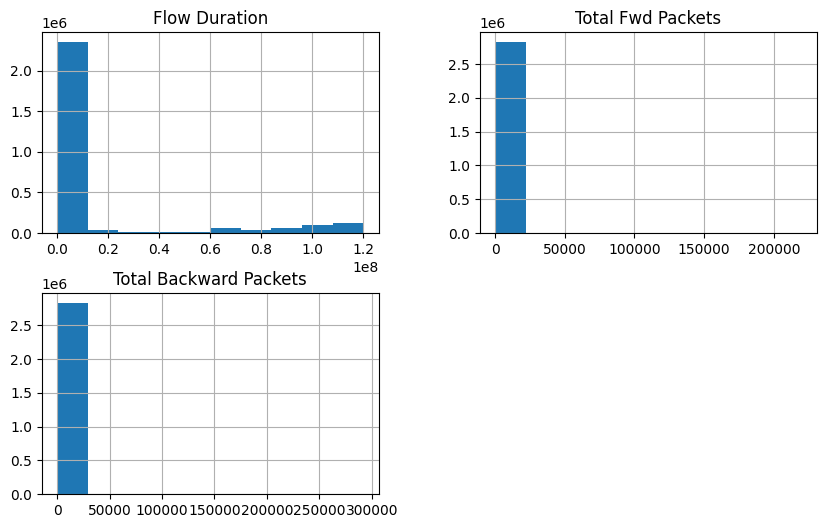

In [16]:
df[['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets']].hist(figsize=(10,6))
plt.show()

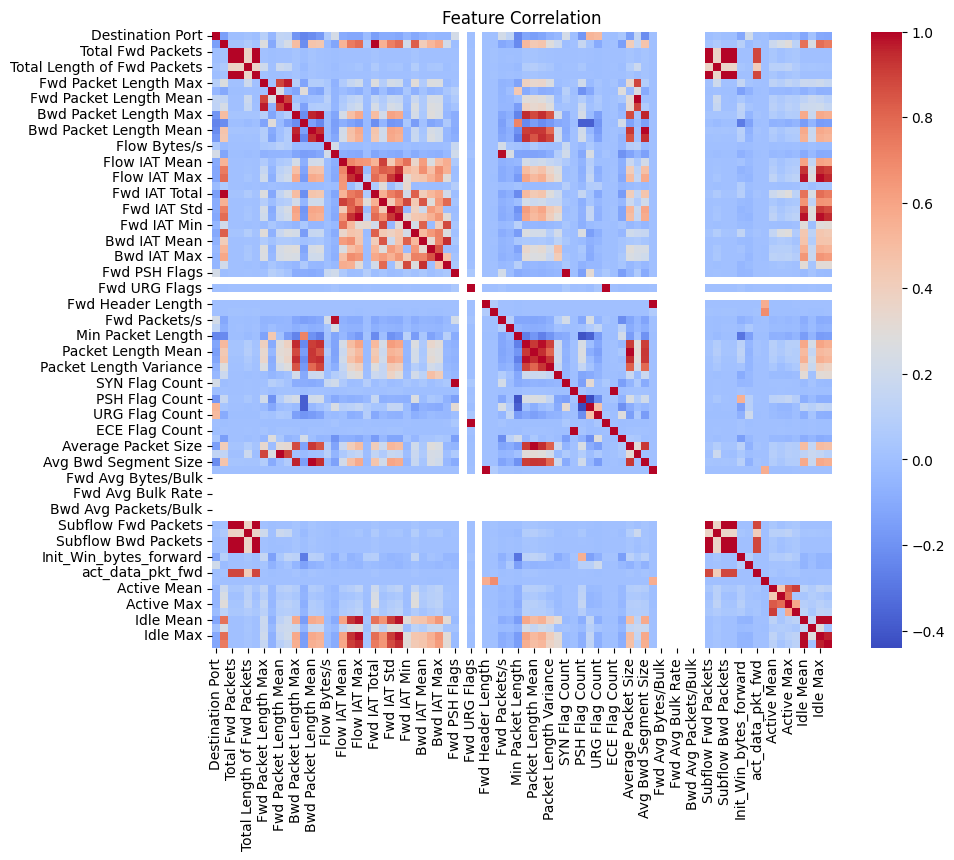

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [18]:
d8.shape

(692703, 79)

In [19]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

In [20]:
#strip whitespace from column names of d8
d8.columns = d8.columns.str.strip()

#replace infinite values with NaN and drop rows with NaN values in d8
d8.replace([np.inf, -np.inf], np.nan, inplace=True)
d8.dropna(inplace=True)

#remove label
X = d8.drop(columns=['Label']).values

#normalize (VERY IMPORTANT for GANs)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#convert to tensor
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

#dataLoader
dataloader = DataLoader(TensorDataset(X_tensor), batch_size=128, shuffle=True)

input_dim = X_tensor.shape[1]
print("Feature dimension:", input_dim)

Feature dimension: 78


In [21]:
import torch.nn as nn

In [22]:
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, output_dim))

    def forward(self, z):
        return self.model(z)

In [23]:
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid())

    def forward(self, x):
        return self.model(x)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 32
G = Generator(latent_dim, input_dim).to(device)
D = Discriminator(input_dim).to(device)
criterion = nn.BCELoss()
optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0002)

In [25]:
# hyperparameters
REAL_LABEL = 0.9    # label smoothing: stops D becoming overconfident
FAKE_LABEL = 0.0
epochs     = 50
G_losses, D_losses = [], []

for epoch in range(epochs):
    g_run = d_run = 0.0

    for (real_data,) in dataloader:
        real_data  = real_data.to(device)
        batch_size = real_data.size(0)
        real_labels = torch.full((batch_size, 1), REAL_LABEL, device=device)
        fake_labels = torch.zeros(batch_size, 1,              device=device)

        #discriminator
        optimizer_D.zero_grad()

        # real
        real_loss = criterion(D(real_data), real_labels)

        # fake — generate once, reuse for both D and G steps
        z=torch.randn(batch_size, latent_dim, device=device)
        fake_data=G(z)
        fake_loss=criterion(D(fake_data.detach()), fake_labels)

        d_loss=real_loss + fake_loss
        d_loss.backward()

        torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=1.0)
        optimizer_D.step()

        #generator
        for _ in range(2):
            optimizer_G.zero_grad()
            z         = torch.randn(batch_size, latent_dim, device=device)
            fake_data = G(z)
            g_loss = criterion(D(fake_data), real_labels)
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
            optimizer_G.step()

        d_run += d_loss.item()
        g_run += g_loss.item()

    n = len(dataloader)
    G_losses.append(g_run / n)
    D_losses.append(d_run / n)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}] | "
              f"D Loss: {D_losses[-1]:.4f} | G Loss: {G_losses[-1]:.4f}")

Epoch [  1/50] | D Loss: 1.2142 | G Loss: 1.0576
Epoch [  5/50] | D Loss: 0.9146 | G Loss: 1.6229
Epoch [ 10/50] | D Loss: 0.9294 | G Loss: 1.5076
Epoch [ 15/50] | D Loss: 0.9336 | G Loss: 1.5520
Epoch [ 20/50] | D Loss: 0.9173 | G Loss: 1.6340
Epoch [ 25/50] | D Loss: 0.8230 | G Loss: 2.2377
Epoch [ 30/50] | D Loss: 0.8016 | G Loss: 2.4015
Epoch [ 35/50] | D Loss: 0.7984 | G Loss: 2.5736
Epoch [ 40/50] | D Loss: 0.7927 | G Loss: 2.5831
Epoch [ 45/50] | D Loss: 0.7946 | G Loss: 2.5475
Epoch [ 50/50] | D Loss: 0.7875 | G Loss: 2.6530


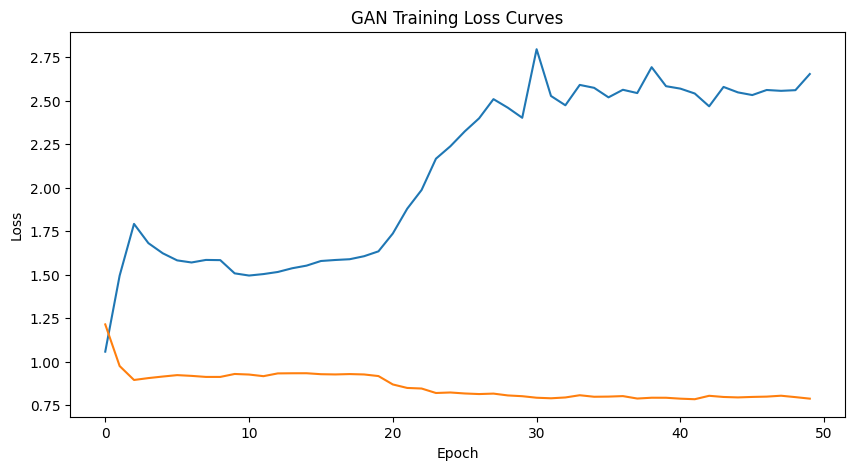

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label='Generator Loss')
plt.plot(D_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN Training Loss Curves')
plt.show()

In [27]:
G.eval()
with torch.no_grad():
    z = torch.randn(1000, latent_dim).to(device)
    fake_samples = G(z).cpu().numpy()
#converting back to original scale
fake_samples = scaler.inverse_transform(fake_samples)
print(fake_samples.shape)

(1000, 78)


In [28]:
real = X[:1000]
print("Real mean:", np.mean(real))
print("Fake mean:", np.mean(fake_samples))
print("Real std:", np.std(real))
print("Fake std:", np.std(fake_samples))

Real mean: 2980377.5157710547
Fake mean: 1504.2988
Real std: 14256238.03403608
Fake std: 138412.23


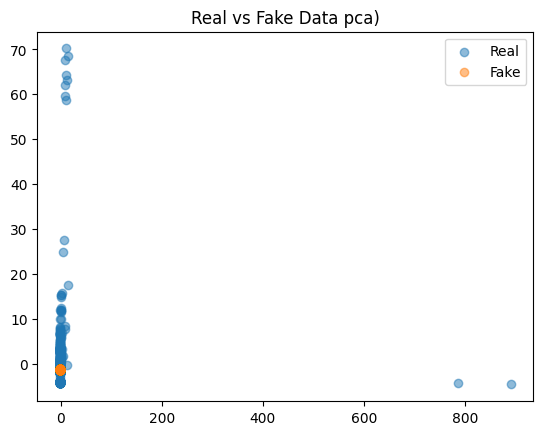

In [29]:
#transform fake into same scale
fake = scaler.transform(fake_samples[:1000])
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
# Use X_scaled (already a numpy array) for real samples
real_pca=pca.fit_transform(X_scaled[:1000])
fake_pca=pca.transform(fake)
plt.scatter(real_pca[:,0], real_pca[:,1], alpha=0.5, label="Real")
plt.scatter(fake_pca[:,0], fake_pca[:,1], alpha=0.5, label="Fake")
plt.legend()
plt.title("Real vs Fake Data pca)")
plt.show()

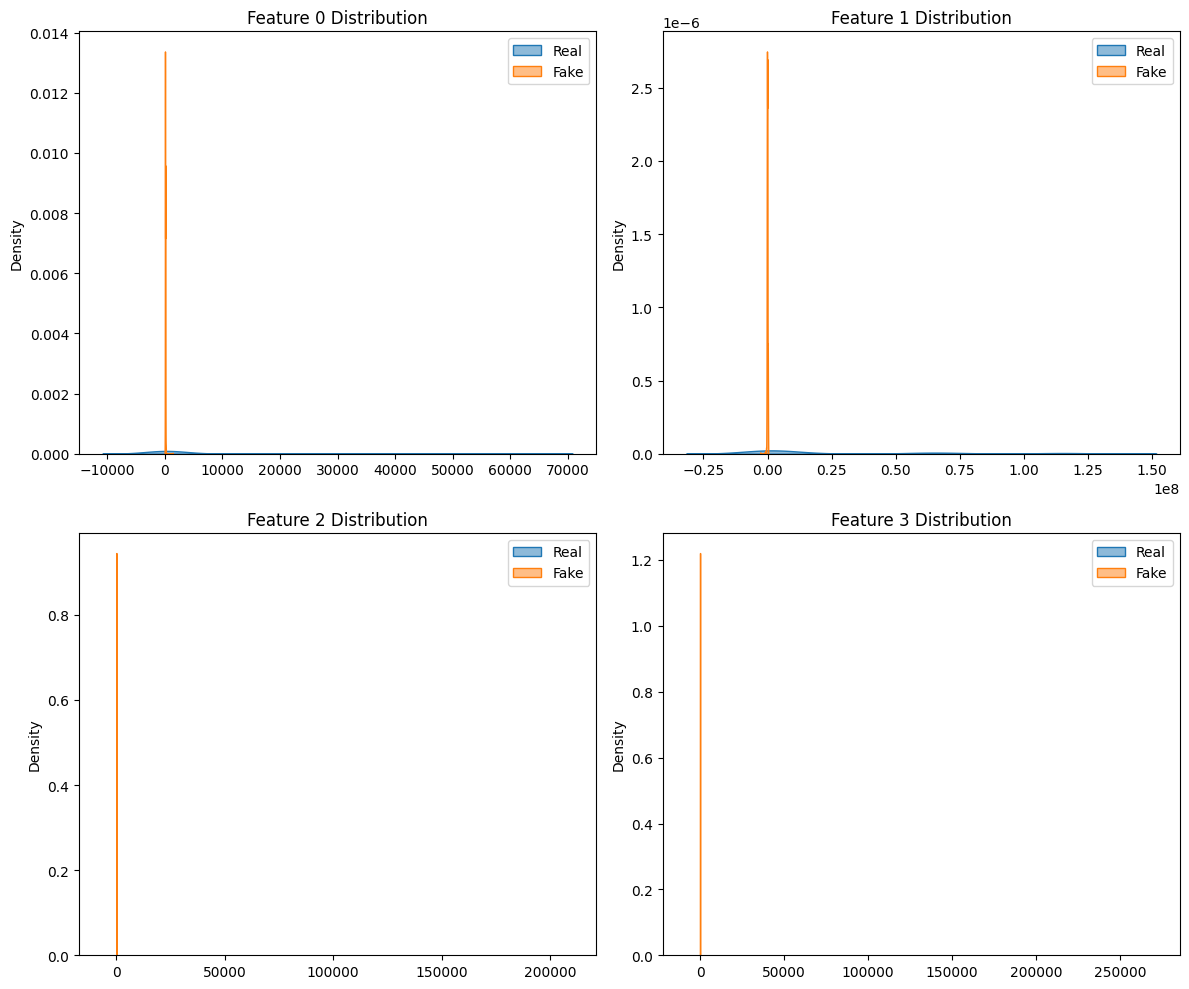

In [30]:
#distributions of the first 4 features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes=axes.flatten()

for i in range(4):
    sns.kdeplot(real[:, i], ax=axes[i], label='Real', fill=True, alpha=0.5)
    sns.kdeplot(fake_samples[:1000, i], ax=axes[i], label='Fake', fill=True, alpha=0.5)
    axes[i].set_title(f'Feature {i} Distribution')
    axes[i].legend()
plt.tight_layout()
plt.show()

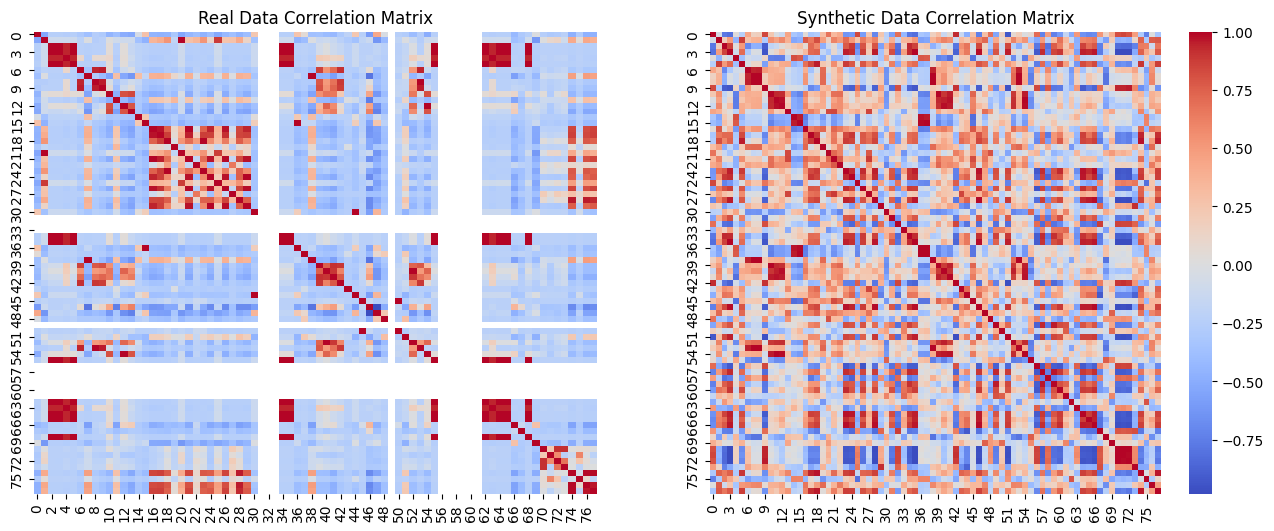

In [31]:
#correlation matrices to see if feature relationships are preserved
real_df=pd.DataFrame(real)
fake_df=pd.DataFrame(fake_samples[:1000])
fig, axes=plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(real_df.corr(), cmap='coolwarm', ax=axes[0], cbar=False)
axes[0].set_title('Real Data Correlation Matrix')
sns.heatmap(fake_df.corr(), cmap='coolwarm', ax=axes[1], cbar=True)
axes[1].set_title('Synthetic Data Correlation Matrix')
plt.show()